# Imports


### **Environment Setup and Dependency Installation**

This cell automates the configuration of the Python environment by installing all necessary libraries listed in the `requirements.txt` file. Additionally, it installs a specific version of PyTorch with CUDA 11.8 support to enable hardware acceleration on NVIDIA GPUs, which is essential for training deep 3D medical imaging models efficiently.


In [1]:
print("Do you want to install the required dependencies? (y/n)")
response = input()
if response == "y":
    %pip install -r requirements.txt
    # To install PyTorch with CUDA support
    %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

    from IPython.display import clear_output

    clear_output()
    print("Dependencies installed successfully!")
else:
    print("Skipping dependency installation.")

Do you want to install the required dependencies? (y/n)
Skipping dependency installation.


### Core Libraries & Environment Setup

This cell imports all the fundamental libraries and dependencies required for the Brain Tumor Segmentation pipeline.


In [2]:
## Third-Party Library Imports
import numpy as np  # For working with large arrays and matrices
import matplotlib.pyplot as plt  # For plotting and visualization
import torch  # For deep learning and tensor computations
import monai  # For medical imaging AI tools and utilities
import sklearn  # For machine learning algorithms and utilities
import scipy  # For scientific computing and image processing
import nibabel as nib  # For loading and working with neuro-imaging data
import optuna  # For hyperparameter optimization and tuning
import tqdm  # For progress bars

## Python Standard Library Imports
import os  # For interacting with the operating system
import shutil  # For high-level file operations
import time  # For measuring execution time
import joblib  # For parallel processing
import json  # For working with JSON data
import random  # For random number generation and shuffling
import itertools  # For efficient looping and combinatorial operations
import warnings  # For managing and suppressing warnings

# Task 1: Understand the Dataset


The training dataset provided for the BraTS21 consists of 1,251 brain MRI scans along with segmentation annotations of tumorous regions. The 3D volumes were skull-stripped and resampled to 1 mm isotropic resolution, with dimensions of (240, 240, 155) voxels.

In the **BraTS 2021 (Brain Tumor Segmentation)** dataset, the training data is organized into subject-specific folders. Each folder typically contains **5 NIfTI files** (`.nii.gz`), representing four different MRI modalities and one ground truth segmentation mask.

---

### 1. `_t1.nii.gz` (Native T1-weighted)

The native T1-weighted scan is the "baseline" structural image. It is excellent for viewing normal brain anatomy.

### 2. `_t1ce.nii.gz` (Post-contrast T1-weighted)

Also known as **T1Gd** (Gadolinium-enhanced), this is a T1-weighted scan taken after a contrast agent (Gadolinium) is injected into the patient.

### 3. `_t2.nii.gz` (T2-weighted)

T2-weighted scans are highly sensitive to water and fluid.

### 4. `_flair.nii.gz` (Fluid Attenuated Inversion Recovery)

FLAIR is a special T2-weighted sequence where the signal from free-flowing water (like CSF) is suppressed or "nullified."

### 5. `_seg.nii.gz` (Ground Truth Segmentation)

This is the manually annotated label file created by expert neuroradiologists. It contains integer values (labels) that categorize each voxel into a specific tumor sub-region:

| Label | Sub-region  | Description                                        |
| :---- | :---------- | :------------------------------------------------- |
| **0** | Background  | Healthy brain tissue or non-brain space.           |
| **1** | **NCR/NET** | Necrotic (dead) and Non-Enhancing tumor core.      |
| **2** | **ED**      | Peritumoral Edema (swelling around the tumor).     |
| **4** | **ET**      | GD-Enhancing Tumor (the active part of the tumor). |

---

### Summary of Tumor Sub-regions

When evaluating models, these labels are usually grouped into three nested classes:

- **Whole Tumor (WT):** Labels 1 + 2 + 4 (Everything abnormal)
- **Tumor Core (TC):** Labels 1 + 4 (The solid tumor)
- **Enhancing Tumor (ET):** Label 4 only

---

---


### **Initial Data Loading and Multi-Modal MRI Visualization**

This code cell handles the initial loading of a specific patient's multi-modal MRI scans (T1, T1ce, T2, FLAIR) and the corresponding ground truth segmentation mask using the Nibabel library. It concludes by generating a side-by-side visual comparison of an axial slice across all four modalities and the label to verify data integrity and spatial alignment.


Shapes of the loaded images and label:
Image - t1 shape: (240, 240, 155)
Image - t1ce shape: (240, 240, 155)
Image - t2 shape: (240, 240, 155)
Image - flair shape: (240, 240, 155)
Label shape: (240, 240, 155)


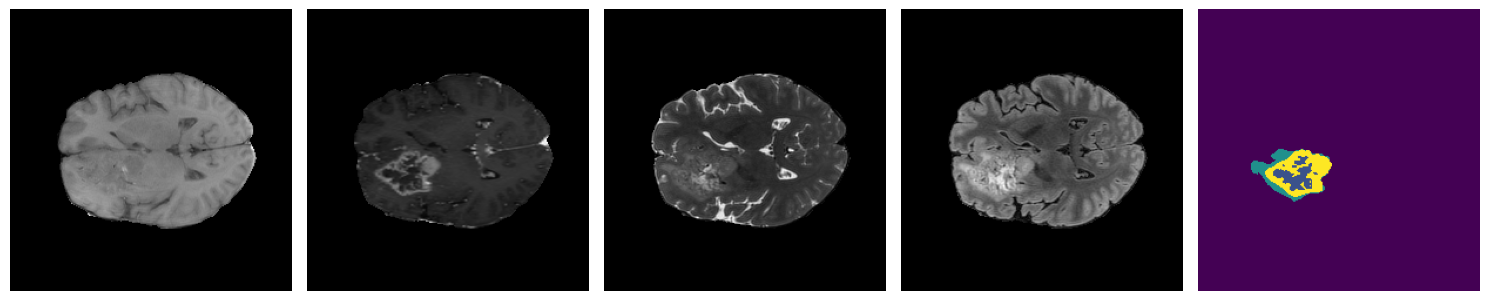

In [3]:
# Modality names in the BraTS dataset and their corresponding file suffixes
modalities = ["t1", "t1ce", "t2", "flair"]

# Load the first subject's data (BraTS2021_00000) for visualization

imgs = [
    nib.load(f"raw/BraTS2021_00000/BraTS2021_00000_{mod}.nii.gz")
    .get_fdata()
    .astype(np.float32)
    for mod in modalities
]
lbl = (
    nib.load("raw/BraTS2021_00000/BraTS2021_00000_seg.nii.gz")
    .get_fdata()
    .astype(np.uint8)
)

print("Shapes of the loaded images and label:")
for i, img in enumerate(imgs):
    print(f"Image - {modalities[i]} shape: {img.shape}")

print(f"Label shape: {lbl.shape}")

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(15, 15))

for i, img in enumerate(imgs):
    axes[i].imshow(img[:, :, 75], cmap="gray")

axes[-1].imshow(lbl[:, :, 75], vmin=0, vmax=4)

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Task 2: Preprocessing & Data Augmentation


### Preprocess MRI scans


### **Workspace Initialization and Data Integrity Management**

This cell configures the directory structure for raw, processed, and training data while performing an integrity check to ensure consistency between input and output folders. It identifies incomplete processing attempts and provides an option to clear and re-synchronize the datasets before beginning the next stage of the pipeline.


In [4]:
# Data directories for raw and processed data
raw_data_path = "raw"
processed_data_path = "processed"
training_data_path = "training"

# Check if the raw data directory exists else raise an error
if not os.path.exists(raw_data_path):
    raise FileNotFoundError(f"Raw data directory '{raw_data_path}' does not exist.")

# Create the processed data directory if it doesn't exist
if not os.path.exists(processed_data_path):
    os.makedirs(processed_data_path)

if not os.path.exists(training_data_path):
    os.makedirs(training_data_path)

# List all subject directories in raw and processed data paths
raw_data_dirs = [
    d
    for d in os.listdir(raw_data_path)
    if os.path.isdir(os.path.join(raw_data_path, d))
]
processed_data_dirs = [
    d
    for d in os.listdir(processed_data_path)
    if os.path.isdir(os.path.join(processed_data_path, d))
]

# If incomplete processing is detected, clear the processed data directory
if len(raw_data_dirs) != len(processed_data_dirs):
    shutil.rmtree(processed_data_path)
    os.makedirs(processed_data_path)

# If all raw data has already been processed, ask the user if they want to reprocess the data
if len(raw_data_dirs) == len(processed_data_dirs):
    print("Total data samples:", len(raw_data_dirs))
    print("All raw data has already been processed.")
    print("Do you want to reprocess the data? (y/n)")
    if input().lower() == "y":
        shutil.rmtree(processed_data_path)
        os.makedirs(processed_data_path)
    processed_data_dirs = [
        d
        for d in os.listdir(processed_data_path)
        if os.path.isdir(os.path.join(processed_data_path, d))
    ]


Total data samples: 1251
All raw data has already been processed.
Do you want to reprocess the data? (y/n)


### **Multi-Threaded Parallel Execution Utility**

This cell defines a helper function that utilizes the `joblib` library to distribute tasks across all available CPU cores for concurrent processing. It is designed to significantly accelerate time-intensive operations, such as MRI data preprocessing, by executing a target function on multiple patient IDs simultaneously rather than sequentially.


In [5]:
# Function to run a given function in parallel across multiple IDs using joblib
def run_parallel(func, ids):
    return joblib.Parallel(n_jobs=os.cpu_count())(
        joblib.delayed(func)(id) for id in ids
    )

### **Dataset Intensity Analysis and Statistical Collection**

This cell implements a robust pipeline to analyze voxel intensity distributions across the entire dataset by focusing specifically on foreground (brain) regions. It calculates critical normalization parameters—including the 0.5th and 99.5th percentiles, global mean, and standard deviation—for each MRI modality to ensure consistent scaling and noise removal during subsequent preprocessing steps.


In [6]:
def collect_intensities(ids):

    intensities_dicts = run_parallel(get_intensities, ids)

    intensities = {}
    intensity_min = {}
    intensity_max = {}
    intensity_mean = {}
    intensity_std = {}

    for mod in modalities:
        # Chain the intensity values from all patients for the current modality into a single list.
        all_values = []
        for d in intensities_dicts:
            all_values.extend(d[mod])
        intensities[mod] = all_values

        # Calculate the 0.5th and 99.5th percentiles to determine the minimum and maximum intensity values for normalization,
        # and calculate the mean and standard deviation for further normalization steps.
        intensity_min[mod] = np.percentile(intensities[mod], [0.5, 99.5])[0]
        intensity_max[mod] = np.percentile(intensities[mod], [0.5, 99.5])[1]
        intensity_mean[mod] = np.mean(intensities[mod])
        intensity_std[mod] = np.std(intensities[mod])

    return {
        "min": intensity_min,
        "max": intensity_max,
        "mean": intensity_mean,
        "std": intensity_std,
    }


def get_intensities(id):
    intensity = {}

    label = (
        nib.load(
            os.path.join(
                raw_data_path,
                f"BraTS2021_{id}",
                f"BraTS2021_{id}_seg.nii.gz",
            )
        )
        .get_fdata()
        .astype(np.uint8)
    )

    for mod in modalities:
        image = (
            nib.load(
                os.path.join(
                    raw_data_path,
                    f"BraTS2021_{id}",
                    f"BraTS2021_{id}_{mod}.nii.gz",
                )
            )
            .get_fdata()
            .astype(np.float32)
        )
        # Extract brain region
        foreground_area = np.where(label > 0)
        # Store the intensity values of the brain region for the current modality in the intensity dictionary as a list.
        intensity[mod] = image[foreground_area].tolist()
    return intensity

### **MRI Data Normalization and Preprocessing Pipeline**

This cell implements the core data transformation workflow by stacking individual 3D MRI modalities into unified 4D NIfTI tensors and applying percentile-based intensity clipping and Z-score standardization. It also handles label preprocessing by remapping specific BraTS class indices to a contiguous range and adding a channel dimension to ensure the masks are compatible with the nnU-Net's loss function requirements.


In [7]:
# Function to preprocess images for a list of IDs in parallel
def preprocess_images(ids):
    run_parallel(process_image, ids)


def process_image(id):
    # Create a directory for the processed data of the current patient
    os.makedirs(os.path.join(processed_data_path, f"BraTS2021_{id}"))

    # Load the image for the current modality and patient
    images = {}
    for mod in modalities:
        image = nib.load(
            os.path.join(
                raw_data_path,
                f"BraTS2021_{id}",
                f"BraTS2021_{id}_{mod}.nii.gz",
            )
        )
        images[mod] = image

    # Save the header and affine of the T1 image to use for the processed image.
    # All modalities have the same header and affine, so we can use the T1 image as a reference.
    img_header = images["t1"].header
    img_affine = images["t1"].affine

    ## Normalize the images
    # Step 1: Clip the intensity values within the minimum and maximum values.
    # Step 2: Normalize the intensity values using the mean and standard deviation.
    normalized_data = {}
    for mod in modalities:
        image = images[mod].get_fdata().astype(np.float32)
        image = np.clip(image, intensity_stats["min"][mod], intensity_stats["max"][mod])
        image = (image - intensity_stats["mean"][mod]) / intensity_stats["std"][mod]
        normalized_data[mod] = image

    # Stack the normalized images of all modalities into a single 4D array with shape (4, 240, 240, 155).
    channels_data = np.stack([normalized_data[mod] for mod in modalities], axis=0)

    # Create a new NIfTI image with the normalized and padded data, using the same affine and header.
    channels_img = nib.Nifti1Image(
        channels_data.astype(np.float32), img_affine, header=img_header
    )

    # Save the processed image for the current patient
    nib.save(
        channels_img,
        os.path.join(
            processed_data_path,
            f"BraTS2021_{id}",
            f"BraTS2021_{id}.nii.gz",
        ),
    )

    # Load the label image for the patient
    label = nib.load(
        os.path.join(
            raw_data_path,
            f"BraTS2021_{id}",
            f"BraTS2021_{id}_seg.nii.gz",
        )
    )
    lbl_header = label.header
    lbl_affine = label.affine
    lbl_data = label.get_fdata().astype(np.uint8)

    # This ensures classes are [0, 1, 2, 3] instead of [0, 1, 2, 4]
    lbl_data[lbl_data == 4] = 3

    # Expand the dimensions of the label data to add a channel dimension
    lbl_data = np.expand_dims(lbl_data, axis=0)

    # Create a new NIfTI image for the label with the same affine and header and save it
    ohc_label = nib.Nifti1Image(
        lbl_data.astype(np.uint8), lbl_affine, header=lbl_header
    )
    nib.save(
        ohc_label,
        os.path.join(
            processed_data_path, f"BraTS2021_{id}", f"BraTS2021_{id}_seg.nii.gz"
        ),
    )

### **Intensity Statistics Management and Batch Preprocessing Control**

This cell orchestrates the preprocessing workflow by generating a sorted list of patient IDs and determining whether to recalculate dataset-wide intensity statistics or use predefined defaults. Once the normalization parameters (Min, Max, Mean, Std) are established, it triggers the parallelized image processing pipeline to transform the raw multi-modal MRI scans into standardized tensors ready for model training.


In [8]:
# Make a list of patient IDs by extracting the last part of the directory names in the raw data directory and sort them
pt_ids = [d.split("_")[-1] for d in raw_data_dirs]
pt_ids.sort()

# If all raw data has already been processed, skip the preprocessing step
if len(raw_data_dirs) != len(processed_data_dirs):
    # Ask if the user wants to recalculate the intensity statistics
    # If No, use the existing intensity statistics which were calculated from a previous run
    # If Yes, collect the intensity values from the raw images for all patients
    print("Do you want to recalculate the intensity statistics? (y/n)")
    if input().lower() != "y":
        print("Using existing intensity statistics.")
        intensity_stats = {
            "min": {"t1": 60.00, "t1ce": 47.00, "t2": 115.00, "flair": 115.00},
            "max": {"t1": 6483.00, "t1ce": 7956.00, "t2": 12371.00, "flair": 13702.00},
            "mean": {"t1": 862.64, "t1ce": 1553.63, "t2": 1901.65, "flair": 1080.03},
            "std": {"t1": 1807.43, "t1ce": 16210.56, "t2": 39182.12, "flair": 4100.89},
        }
    else:
        print("Collecting intensity values for normalization...")
        intensity_start = time.time()
        intensity_stats = collect_intensities(pt_ids)
        intensity_end = time.time()
        print(
            f"Intensities collected in {intensity_end - intensity_start:.2f} seconds."
        )

    print("Intensity statistics:")
    print("Min:", intensity_stats["min"])
    print("Max:", intensity_stats["max"])
    print("Mean:", intensity_stats["mean"])
    print("Std:", intensity_stats["std"])

    # Preprocess the images for all patients
    print("Processing raw data...")
    preprocessing_start = time.time()
    preprocess_images(pt_ids)
    preprocessing_end = time.time()
    print(
        f"Image preprocessing completed in {preprocessing_end - preprocessing_start:.2f} seconds."
    )
else:
    print("Preprocessing skipped. All data is already processed.")

Preprocessing skipped. All data is already processed.


### Data Augmentation


### **Data Augmentation and Spatial Transformation Suite**

This cell implements a comprehensive suite of 3D data augmentation functions designed to increase the diversity of the training set and improve model generalization. It includes sophisticated spatial operations like biased foreground cropping and random zooming, alongside intensity-based perturbations such as Gaussian noise, blurring, and brightness/contrast adjustments to simulate varied MRI scanner conditions.


In [9]:
def biased_crop(image, label, crop_size):
    """1. Biased crop with 0.4 prob to guarantee foreground."""
    _, d, h, w = image.shape
    cd, ch, cw = crop_size

    if np.random.rand() < 0.4 and np.any(label > 0):
        fg_indices = np.argwhere(label > 0)
        center_voxel = fg_indices[np.random.choice(len(fg_indices))]

        _, z, y, x = center_voxel

        z_start = max(0, min(z - cd // 2, d - cd))
        y_start = max(0, min(y - ch // 2, h - ch))
        x_start = max(0, min(x - cw // 2, w - cw))
    else:
        z_start = np.random.randint(0, d - cd + 1)
        y_start = np.random.randint(0, h - ch + 1)
        x_start = np.random.randint(0, w - cw + 1)

    cropped_img = image[
        :, z_start : z_start + cd, y_start : y_start + ch, x_start : x_start + cw
    ]

    cropped_lbl = label[
        :, z_start : z_start + cd, y_start : y_start + ch, x_start : x_start + cw
    ]

    return cropped_img, cropped_lbl


def center_crop(image, label, crop_size):
    """Helper for validation consistency."""
    _, d, h, w = image.shape
    cd, ch, cw = crop_size

    z_start = (d - cd) // 2
    y_start = (h - ch) // 2
    x_start = (w - cw) // 2

    cropped_img = image[
        :, z_start : z_start + cd, y_start : y_start + ch, x_start : x_start + cw
    ]

    cropped_lbl = label[
        :, z_start : z_start + cd, y_start : y_start + ch, x_start : x_start + cw
    ]

    return cropped_img, cropped_lbl


def apply_zoom(image, label, chance):
    """2. Zoom (0.15 prob, 1.0 to 1.4)."""
    if np.random.rand() < chance:
        zoom_factor = np.random.uniform(1.0, 1.4)
        # Do not zoom the channel dimension
        zoom_tuple = (1.0, zoom_factor, zoom_factor, zoom_factor)

        # Cubic interpolation (order=3) for image, Nearest Neighbor (order=0) for label
        img_size = image.shape[1:]
        image = scipy.ndimage.zoom(image, zoom_tuple, order=3, mode="nearest")

        label = scipy.ndimage.zoom(
            label,
            zoom_tuple,
            order=0,
            mode="nearest",
        )

        # Crop back down to original size after zooming
        image, label = center_crop(image, label, img_size)

    return image, label


def apply_flips(image, label, chance):
    # Axes for D, H, W (skipping Channel at index 0)
    axes = [1, 2, 3]

    for axis in axes:
        if np.random.rand() < chance:
            image = np.flip(image, axis=axis)
            label = np.flip(label, axis=axis)

    # np.flip can result in non-contiguous arrays which can cause issues with some libraries
    # np.ascontiguousarray makes a copy of the array with contiguous memory layout.
    image = np.ascontiguousarray(image)
    label = np.ascontiguousarray(label)

    return image, label


def apply_gaussian_noise(image, chance):
    if np.random.rand() < chance:
        #  Select a random standard deviation between 0.0 and 0.33
        std = np.random.uniform(0.0, 0.33)
        # Generate Gaussian noise with mean 0 and the selected standard deviation
        noise = np.random.normal(0, std, image.shape)
        # Apply noise
        image = image + noise
    return image.astype(np.float32)


def apply_gaussian_blur(image, chance):
    if np.random.rand() < chance:
        # Select a random sigma value between 0.5 and 1.5 for the Gaussian blur
        sigma = np.random.uniform(0.5, 1.5)
        # Apply Blur
        image = scipy.ndimage.gaussian_filter(image, sigma=(0, sigma, sigma, sigma))
    return image


def apply_brightness(image, chance):
    if np.random.rand() < chance:
        # Select a random brightness factor between 0.7 and 1.3
        factor = np.random.uniform(0.7, 1.3)
        # Apply brightness adjustment
        image = image * factor
    return image


def apply_contrast(image, chance):
    if np.random.rand() < chance:
        # Select a random contrast factor between 0.65 and 1.5
        factor = np.random.uniform(0.65, 1.5)
        img_min, img_max = image.min(), image.max()
        # Apply contrast adjustment
        image = image * factor
        # Clip back to original min/max values
        image = np.clip(image, img_min, img_max)
    return image

### **Integrated Augmentation Pipeline for Training and Validation**

This cell defines an integrated augmentation controller that conditionally applies a sequence of seven distinct spatial and intensity transformations during the training phase to maximize model robustness. During validation or testing, it switches to a deterministic center-cropping strategy, ensuring consistent input dimensions ($128^3$) and reproducible evaluation results across the dataset.


In [10]:
def apply_augmentation(image, label, isTraining=True):
    # 15% chance to apply each augmentation independently
    chance = 0.15
    crop_size = (128, 128, 128)
    if isTraining:
        image, label = biased_crop(image, label, crop_size)
        image, label = apply_zoom(image, label, chance)
        image, label = apply_flips(image, label, chance)
        image = apply_gaussian_noise(image, chance)
        image = apply_gaussian_blur(image, chance)
        image = apply_brightness(image, chance)
        image = apply_contrast(image, chance)
    else:
        # If testing/validating, apply standard center crop to match dimensions
        image, label = center_crop(image, label, crop_size)

    return image, label

### Loading Dataset


### **Custom PyTorch Dataset for BraTS Data Loading**

This cell defines the `BraTSDataset` class, which inherits from PyTorch's Dataset module to enable efficient, on-the-fly loading of 3D NIfTI images and segmentation masks. It integrates the previously defined data augmentation pipeline to transform samples during training and automatically converts NumPy arrays into PyTorch tensors for seamless integration with the model training loop.


In [11]:
class BraTSDataset(torch.utils.data.Dataset):
    def __init__(self, data_path, pt_ids, isTraining=True):
        self.data_path = data_path
        self.pt_ids = pt_ids
        self.isTraining = isTraining

    # Required: PyTorch needs to know how many total patients there are
    def __len__(self):
        return len(self.pt_ids)

    # Required: PyTorch needs to know how to get the next item
    def __getitem__(self, idx):
        pt_id = self.pt_ids[idx]

        img_path = os.path.join(
            self.data_path, f"BraTS2021_{pt_id}", f"BraTS2021_{pt_id}.nii.gz"
        )
        lbl_path = os.path.join(
            self.data_path, f"BraTS2021_{pt_id}", f"BraTS2021_{pt_id}_seg.nii.gz"
        )

        image = nib.load(img_path).get_fdata().astype(np.float32)
        label = nib.load(lbl_path).get_fdata().astype(np.uint8)

        # Apply data augmentation to the image and label if in training mode
        image, label = apply_augmentation(image, label, self.isTraining)

        # Convert from numpy arrays to PyTorch tensors
        image, label = torch.from_numpy(image), torch.from_numpy(label)

        return image, label

### **Data Splitting and DataLoader Configuration**

This cell partitions the dataset into training and validation sets using a stratified 80-20 split to ensure impartial model evaluation. It then initializes PyTorch DataLoaders with a batch size of 2, specifically enabling random shuffling for the training set to prevent sequence bias and maintain deterministic ordering for validation consistency.


In [12]:
# Split the patient IDs into training and testing sets using an 80-20 split.
train_ids, test_ids = sklearn.model_selection.train_test_split(
    pt_ids, test_size=0.2, random_state=123
)

training_dataset = BraTSDataset(processed_data_path, train_ids, isTraining=True)
train_loader = torch.utils.data.DataLoader(training_dataset, batch_size=2, shuffle=True)

val_dataset = BraTSDataset(processed_data_path, test_ids, isTraining=False)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=2, shuffle=False)

# Task 3: Implementing the nnU-Net Model


### 3D nnU-Net Architecture Description

---

### 1. The Building Block: `ConvBlock`

The `ConvBlock` is the fundamental unit repeated throughout both the encoder and decoder. It consists of a double convolution sequence:
`Conv3d -> InstanceNorm3d -> LeakyReLU -> Conv3d -> InstanceNorm3d -> LeakyReLU`

**Design Choices & Reasoning:**

- **3D Convolutions (`nn.Conv3d`):** Medical images like MRIs are volumetric (Depth, Height, Width). 3D convolutions are necessary to capture spatial context across all three dimensions simultaneously, which 2D convolutions would miss.
- **`kernel_size=3, padding=1`:** This standard configuration ensures that the convolutional operation itself does not shrink the spatial dimensions of the feature maps, allowing depth/resolution changes to be explicitly controlled by strides.
- **`bias=False`:** Because the convolution is immediately followed by an Instance Normalization layer (which introduces its own bias/shift parameters), adding a bias to the convolution is redundant and wastes memory.
- **Instance Normalization (`nn.InstanceNorm3d`):** Unlike 2D image tasks that use Batch Normalization, 3D medical imaging models consume massive amounts of VRAM, forcing batch sizes to be very small (often 1 or 2). Batch Normalization performs poorly with small batch sizes. Instance Normalization normalizes across each channel of each individual sample, making it highly stable regardless of batch size.
- **Leaky ReLU (`nn.LeakyReLU`):** Replaces the standard ReLU to prevent the "dying neuron" problem. By allowing a small, non-zero gradient when the input is negative, it helps the network continue learning even when weights fall below zero.

---

### 2. The Encoder (Downsampling Path)

The encoder extracts hierarchical features from the input MRI. As the network gets deeper, it reduces the spatial resolution while increasing the number of feature channels (from 4 to 320).

**Design Choices & Reasoning:**

- **Input Channels (4):** Designed to accept the 4 standard BraTS MRI modalities stacked together: T1, T1ce (contrast-enhanced), T2, and FLAIR.
- **Strided Convolutions for Downsampling:** Notice that starting from `enc2`, the `ConvBlock` is passed a `stride=2`. Instead of using separate `MaxPool3d` layers, the model uses strided convolutions to halve the spatial dimensions. This allows the network to _learn_ the optimal pooling operation rather than relying on a fixed mathematical operation.
- **Memory-Efficient Channel Scaling:** A standard U-Net doubles channels at every level (32 $\rightarrow$ 64 $\rightarrow$ 128 $\rightarrow$ 256 $\rightarrow$ 512 $\rightarrow$ 1024). Because 3D data is so large, pushing channels to 512 or 1024 would crash most consumer GPUs. This model intelligently caps the channels at **320** at Level 5 and the Bottleneck to maintain high-level feature extraction without exceeding VRAM limits.

---

### 3. The Bottleneck (Level 6)

The bottleneck (`self.bottleneck = ConvBlock(320, 320, 2)`) sits at the very bottom of the "U".

**Design Choices & Reasoning:**

- **Deepest Semantic Representation:** At this stage, the spatial dimensions are highly compressed, but the channels are rich with semantic context. The network knows "what" it is looking at (e.g., tumor core vs. edema) but has lost the precise spatial boundaries of "where" it is.

---

### 4. The Decoder (Upsampling Path)

The decoder reconstructs the spatial resolution to match the original image size, transforming the deep semantic features back into voxel-level predictions.

**Design Choices & Reasoning:**

- **Transposed Convolutions (`nn.ConvTranspose3d`):** Layers like `self.up5` use `stride=2` and `kernel_size=2` to double the spatial dimensions (Depth, Height, Width) of the feature maps, physically enlarging the tensor.
- **Skip Connections (`torch.cat([..., ...], dim=1)`):** This is the most crucial part of the U-Net. The upsampled features from the decoder are concatenated with the high-resolution features saved from the corresponding level of the encoder.
- _Why?_ The encoder features contain the sharp, fine-grained spatial boundaries (the "where") that were lost during downsampling. The decoder features contain the deep context (the "what"). Concatenating them gives the subsequent `ConvBlock` the best of both worlds, allowing it to draw highly precise segmentation masks.

- **Channel Compression:** When the 320 upsampled channels are concatenated with the 320 skip-connection channels in `dec5`, the input tensor becomes 640 channels deep. `dec5` immediately compresses this back down to 320. This pattern continues (512 $\rightarrow$ 256, etc.) as the network builds its way back up.

---

### 5. Final Segmentation Head

`self.final_conv = torch.nn.Conv3d(32, out_channels, kernel_size=1)`

**Design Choices & Reasoning:**

- **1x1x1 Convolution:** A 1x1 convolution acts as a voxel-wise linear classifier. It doesn't look at neighboring voxels; instead, it looks _across_ the 32 remaining feature channels and collapses them down to the final `out_channels=4`.
- **Output Channels (4):** This outputs raw logits for the 4 expected classes in the BraTS dataset (typically: 0=Background, 1=Necrotic Tumor Core, 2=Peritumoral Edema, 3=Enhancing Tumor). These logits would then be passed through a Softmax or Sigmoid function depending on the specific loss function (e.g., Cross-Entropy or Dice Loss) used during training.

---

---


## Defining the Model Architecture


### **Core nnU-Net Model Architecture and 3D Convolutional Blocks**

This cell defines the hierarchical structure of the 3D nnU-Net, starting with standardized convolutional blocks that utilize Instance Normalization and LeakyReLU for stable feature extraction. The main class assembles a symmetric 6-level encoder-decoder network, employing strided convolutions for downsampling and transpose convolutions for upsampling, integrated with skip connections to preserve high-resolution spatial details for precise tumor segmentation.


In [13]:
class ConvBlock(torch.nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = torch.nn.Conv3d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False,
            stride=stride,
        )
        self.norm1 = torch.nn.InstanceNorm3d(out_channels)
        self.relu1 = torch.nn.LeakyReLU(inplace=True)

        self.conv2 = torch.nn.Conv3d(
            out_channels, out_channels, kernel_size=3, padding=1, bias=False
        )
        self.norm2 = torch.nn.InstanceNorm3d(out_channels)
        self.relu2 = torch.nn.LeakyReLU(inplace=True)

    def forward(self, x):
        return self.relu2(self.norm2(self.conv2(self.relu1(self.norm1(self.conv1(x))))))


class nnUNet(torch.nn.Module):
    def __init__(self):
        super().__init__()

        in_channels = 4  # T1, T1ce, T2, FLAIR
        out_channels = 4  # Background, Necrotic Core, Edema, Enhancing Tumor

        # --- ENCODER ---
        # Encoder Level 1
        self.enc1 = ConvBlock(in_channels, 32)
        # Encoder Level 2
        self.enc2 = ConvBlock(32, 64, 2)
        # Encoder Level 3
        self.enc3 = ConvBlock(64, 128, 2)
        # Encoder Level 4
        self.enc4 = ConvBlock(128, 256, 2)
        # Encoder Level 5
        self.enc5 = ConvBlock(256, 320, 2)
        # Bottleneck (Level 6)
        self.bottleneck = ConvBlock(320, 320, 2)

        # --- DECODER ---
        # Decoder Level 5
        self.up5 = torch.nn.ConvTranspose3d(320, 320, kernel_size=2, stride=2)
        self.dec5 = ConvBlock(640, 320)
        # Decoder Level 4
        self.up4 = torch.nn.ConvTranspose3d(320, 256, kernel_size=2, stride=2)
        self.dec4 = ConvBlock(512, 256)
        # Decoder Level 3
        self.up3 = torch.nn.ConvTranspose3d(256, 128, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(256, 128)
        # Decoder Level 2
        self.up2 = torch.nn.ConvTranspose3d(128, 64, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(128, 64)
        # Decoder Level 1
        self.up1 = torch.nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(64, 32)
        # Decoder Level 0 (Final Convolution)
        self.final_conv = torch.nn.Conv3d(32, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e5 = self.enc5(e4)

        # Bottleneck
        b = self.bottleneck(e5)

        # Decoder
        d5 = self.dec5(torch.cat([self.up5(b), e5], dim=1))
        d4 = self.dec4(torch.cat([self.up4(d5), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        # Final Convolution
        f = self.final_conv(d1)

        return f

## Model Training


### Evaluation Metrics


### **Segmentation Performance Evaluation Metrics**

This code cell defines a comprehensive evaluation function to quantify the accuracy of the model's predictions by comparing them against the ground truth labels. It calculates five essential medical imaging metrics—Dice Score, Intersection over Union (IoU), Sensitivity (Recall), Specificity, and Precision—averaging them across the relevant tumor sub-regions to provide a detailed assessment of segmentation quality.


In [14]:
def compute_metrics(predictions, targets):

    # Convert logits to class predictions
    preds_cls = torch.argmax(predictions, dim=1)

    # Ensure targets are the same shape as predictions (remove channel dim if present)
    targets_cls = targets.squeeze(1) if targets.ndim == 5 else targets

    dice, iou, sens, spec, prec = 0.0, 0.0, 0.0, 0.0, 0.0
    epsilon = 1e-9  # Small constant to prevent division by zero

    # Calculate for tumor classes only (1 to 3)
    classes_to_eval = range(1, 4)
    for c in classes_to_eval:
        p = preds_cls == c
        t = targets_cls == c

        # True Positives (TP): Both prediction and target are the class
        tp = (p & t).sum().float()
        # False Positives (FP): Prediction is the class but target is not
        fp = (p & ~t).sum().float()
        # True Negatives (TN): Both prediction and target are not the class
        tn = (~p & ~t).sum().float()
        # False Negatives (FN): Target is the class but prediction is not
        fn = (~p & t).sum().float()

        # DICE Score
        dice += (2 * tp) / (2 * tp + fp + fn + epsilon)
        # IoU Score (Intersection over Union)
        iou += tp / (tp + fp + fn + epsilon)
        # Sensitivity (Recall): How many actual positives were correctly identified
        sens += tp / (tp + fn + epsilon)
        # Specificity: How many actual negatives were correctly identified
        spec += tn / (tn + fp + epsilon)
        # Precision: How many predicted positives were actually positive
        prec += tp / (tp + fp + epsilon)

    num_eval_classes = len(classes_to_eval)
    return (
        (dice / num_eval_classes).item(),
        (iou / num_eval_classes).item(),
        (sens / num_eval_classes).item(),
        (spec / num_eval_classes).item(),
        (prec / num_eval_classes).item(),
    )

### Hyperparameter Tunning


### **Hyperparameter Optimization with Optuna and Mixed Precision Training**

This cell defines a modular objective function for hyperparameter tuning using the Optuna framework, focusing on optimizing the learning rate and weight decay for the nnU-Net model. It incorporates advanced training features such as automated mixed precision (AMP) to accelerate computations on both CPU and GPU, VRAM management through cache clearing, and early trial pruning to efficiently find the best performing model configuration.


In [15]:
def tuner(trial):
    # Dynamically determine device type for both tensor allocation and AMP
    device_type = "cuda" if torch.cuda.is_available() else "cpu"
    device = torch.device(device_type)

    # 1. Define the hyperparameters we want Optuna to tune
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

    # 2. Initialize Model, Loss, and Optimizer
    model = nnUNet().to(device)

    criterion = monai.losses.DiceCELoss(to_onehot_y=True, softmax=True, batch=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scaler = torch.amp.GradScaler(device_type) if device_type == "cuda" else None

    num_tuning_epochs = 5

    for epoch in range(num_tuning_epochs):
        model.train()
        for batch_data, batch_labels in train_loader:
            batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)

            optimizer.zero_grad()

            # Mixed precision training (safe for both CPU and GPU)
            with torch.amp.autocast(
                device_type=device_type,
                dtype=torch.float16 if device_type == "cuda" else torch.bfloat16,
            ):
                outputs = model(batch_data)
                loss = criterion(outputs, batch_labels)

            if scaler is not None:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

        # Free up VRAM before validation (Critical for 3D BraTS scans)
        if device_type == "cuda":
            torch.cuda.empty_cache()

        # --- Validation Phase ---
        model.eval()
        val_dice_sum = 0.0
        batches = 0

        with torch.no_grad():
            for val_data, val_labels in val_loader:
                val_data, val_labels = val_data.to(device), val_labels.to(device)

                with torch.amp.autocast(
                    device_type=device_type,
                    dtype=torch.float16 if device_type == "cuda" else torch.bfloat16,
                ):
                    val_outputs = model(val_data)
                    # compute_metrics might return a tuple, grabbing the first element (avg dice)
                    val_dice = compute_metrics(val_outputs, val_labels)[0]

                val_dice_sum += val_dice
                batches += 1

        avg_val_dice = val_dice_sum / batches

        # Free up VRAM before next epoch
        if device_type == "cuda":
            torch.cuda.empty_cache()

        # Report intermediate values to Optuna
        trial.report(avg_val_dice, epoch)

        # Prune (stop) unpromising trials early to save massive amounts of GPU time
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    # Return the metric we want to maximize
    return avg_val_dice

### **Automated Hyperparameter Optimization Study Control**

This cell initializes and executes an Optuna study aimed at maximizing the average validation Dice Score by iterating through 15 different combinations of learning rates and weight decay values. Once complete, it extracts the best-performing parameters and resets the study variables, providing a data-driven foundation for the final model training phase.


In [16]:
def tune_hyperparameters():
    # We want to MAXIMIZE the Dice Score
    study = optuna.create_study(
        direction="maximize", study_name="Hyperparameter_Tuning"
    )

    # Run 15 different trial combinations
    study.optimize(tuner, n_trials=15)

    print("\n--- Tuning Complete ---")
    print("Best Trial:")
    trial = study.best_trial
    print(f"  Validation Dice Value: {trial.value}")
    print("  Best Hyperparameters:")
    for key, value in trial.params.items():
        print(f"    {key}: {value}")

    lr = trial.params.items()["lr"]
    decay = trial.params.items()["weight_decay"]

    return lr, decay

### Training Setup


### **Training Environment and Optimization Engine Configuration**

This cell configures the essential training components for the nnU-Net, including the AdamW optimizer and a Cosine Annealing learning rate scheduler to manage convergence. It also initializes a medical-specific Dice plus Cross-Entropy loss function and a mixed-precision gradient scaler to optimize GPU memory usage and computational speed during the training process.


In [17]:
def setup_training(model, lr, decay):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on device: {device}")
    model = model.to(device)

    # AdamW Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=decay)
    # Dice + Cross-Entropy Loss
    criterion = monai.losses.DiceCELoss(to_onehot_y=True, softmax=True, batch=True)
    # Cosine Annealing Learning Rate Scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
    # Mixed Precision Gradient Scaler for faster training on GPU
    scaler = torch.amp.GradScaler("cuda") if torch.cuda.is_available() else None

    return device, model, optimizer, criterion, scheduler, scaler

### **Training State Restoration and Checkpoint Management**

This cell implements a robust state recovery system that enables the training process to resume seamlessly from a specific checkpoint or restart from scratch if no prior state is found. It handles the restoration of model weights, optimizer parameters, and learning rate scheduler states, while also reloading the JSON-formatted metrics history to maintain a continuous record of the model's performance across multiple sessions.


In [18]:
def load_training_state(
    model,
    optimizer,
    scheduler,
    device,
    json_log_path="training/training_metrics.json",
    resume_checkpoint="training/model.pth",
):
    metrics_history = []
    start_epoch = 0
    best_val_loss = float("inf")
    epochs_no_improve = 0

    # Load JSON Metrics
    if os.path.exists(json_log_path):
        print(f"=> Found existing metrics log '{json_log_path}'. Loading data...")
        with open(json_log_path, "r") as f:
            metrics_history = json.load(f)
    else:
        print(f"=> No existing metrics log found. Will create '{json_log_path}'.")

    # Load Checkpoint
    if os.path.isfile(resume_checkpoint):
        print(f"=> Loading checkpoint '{resume_checkpoint}'...")
        checkpoint = torch.load(resume_checkpoint, map_location=device)

        start_epoch = checkpoint["epoch"] + 1
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        best_val_loss = checkpoint["best_val_loss"]
        epochs_no_improve = checkpoint["epochs_no_improve"]

        print(
            f"=> Resuming training from epoch {start_epoch + 1} (Best Val Loss: {best_val_loss:.4f})"
        )
    else:
        print(
            f"=> Warning: Checkpoint '{resume_checkpoint}' not found. Starting from scratch."
        )

    return start_epoch, best_val_loss, epochs_no_improve, metrics_history

### **Single-Epoch Model Training Logic**

This cell implements the core training logic for a single epoch, utilizing automated mixed precision (AMP) and gradient scaling to accelerate computations on the GPU. It manages the full forward and backward pass sequence—including gradient zeroing, loss calculation, and weight optimization—while providing real-time progress updates and VRAM cache management to prevent memory overflow during the processing of intensive 3D MRI batches.


In [19]:
def train_epoch(
    model, train_loader, optimizer, criterion, scaler, device, epoch, num_epochs
):

    # Free up VRAM before validation (Critical for 3D BraTS scans)
    if device.type == "cuda":
        torch.cuda.empty_cache()

    model.train()
    train_loss = 0.0
    train_pbar = tqdm.tqdm(
        train_loader, desc=f"Epoch {epoch + 1}/{num_epochs} [Train]", leave=False
    )

    for images, labels in train_pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast(
            device_type=device.type,
            dtype=torch.float16 if device.type == "cuda" else torch.bfloat16,
        ):
            outputs = model(images)
            loss = criterion(outputs, labels)

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        train_loss += loss.item()
        train_pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    return train_loss / len(train_loader)

### **Model Validation Logic and Multi-Metric Evaluation**

This cell defines the validation routine used to monitor model performance on unseen data during the training process. It disables gradient calculations to save memory, performs a full forward pass on the validation set, and computes an average across multiple key clinical metrics—including Dice Score, IoU, Sensitivity, Specificity, and Precision—to provide a comprehensive assessment of the nnU-Net's segmentation accuracy.


In [20]:
def validate_epoch(model, val_loader, criterion, device, epoch, num_epochs):

    # Free up VRAM before validation (Critical for 3D BraTS scans)
    if device.type == "cuda":
        torch.cuda.empty_cache()

    model.eval()
    val_loss = 0.0
    epoch_metrics = {"dice": 0.0, "iou": 0.0, "sens": 0.0, "spec": 0.0, "prec": 0.0}

    val_pbar = tqdm.tqdm(
        val_loader, desc=f"Epoch {epoch + 1}/{num_epochs} [Val]", leave=False
    )

    with torch.no_grad():
        for images, labels in val_pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            b_dice, b_iou, b_sens, b_spec, b_prec = compute_metrics(outputs, labels)
            epoch_metrics["dice"] += b_dice
            epoch_metrics["iou"] += b_iou
            epoch_metrics["sens"] += b_sens
            epoch_metrics["spec"] += b_spec
            epoch_metrics["prec"] += b_prec

            val_pbar.set_postfix(
                {
                    "loss": f"{loss.item():.4f}",
                    "dice": f"{b_dice:.4f}",
                    "iou": f"{b_iou:.4f}",
                }
            )

    num_batches = len(val_loader)
    avg_val_loss = val_loss / num_batches
    avg_metrics = {k: v / num_batches for k, v in epoch_metrics.items()}

    return avg_val_loss, avg_metrics

### **Epoch Results Logging and Checkpoint Management**

This cell implements a comprehensive persistence layer that records per-epoch performance metrics—such as loss, Dice Score, and clinical accuracy—into a structured JSON log for long-term tracking. It also manages the model's physical state by saving the "best" weights whenever validation loss improves and maintaining a "latest" checkpoint that captures the complete optimizer and scheduler states to enable seamless training recovery.


In [21]:
def save_epoch_results(
    epoch,
    model,
    optimizer,
    scheduler,
    avg_train_loss,
    avg_val_loss,
    avg_metrics,
    best_val_loss,
    epochs_no_improve,
    metrics_history,
    json_log_path="training/training_metrics.json",
):

    # 1. Save to JSON
    epoch_data = {
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "val_dice": avg_metrics["dice"],
        "val_iou": avg_metrics["iou"],
        "val_sensitivity": avg_metrics["sens"],
        "val_specificity": avg_metrics["spec"],
        "val_precision": avg_metrics["prec"],
        "learning_rate": scheduler.get_last_lr()[0],
    }
    metrics_history.append(epoch_data)
    with open(json_log_path, "w") as f:
        json.dump(metrics_history, f, indent=4)

    # 2. Checkpointing logic
    if avg_val_loss < best_val_loss:
        print(
            f"  -> Validation loss improved from {best_val_loss:.4f} to {avg_val_loss:.4f}. Saving best model..."
        )
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(
            f"  -> No improvement in validation loss for {epochs_no_improve} epoch(s)."
        )

    checkpoint_state = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val_loss": best_val_loss,
        "epochs_no_improve": epochs_no_improve,
    }
    torch.save(checkpoint_state, "training/model.pth")

    return best_val_loss, epochs_no_improve

## Train the model


### **Main Training Orchestration and Early Stopping Control**

This cell serves as the central engine for the model's development, integrating hyperparameter tuning, state restoration, and the primary training loop. It coordinates the execution of training and validation phases across 30 epochs, automatically managing GPU memory and utilizing an early stopping mechanism to terminate training if validation performance fails to improve for 5 consecutive epochs, ensuring the most optimized version of the nnU-Net is preserved.


In [22]:
model = nnUNet()

print("Do you want to tune hyperparameters? (y/n)")
if input().lower() != "y":
    print("Using existing hyperparameters. Learning Rate: 1e-4, Decay: 1e-5")
    LEARNING_RATE = 1e-4
    DECAY = 1e-5
else:
    print("Hyperparameter tunning started...")
    tuning_start = time.time()
    LEARNING_RATE, DECAY = tune_hyperparameters()
    tuning_end = time.time()
    print(f"Hyperparameters tuned in {tuning_end - tuning_start:.2f} seconds.")

NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
DECAY = 1e-5
PATIENCE = 5

# 1. Setup
device, model, optimizer, criterion, scheduler, scaler = setup_training(
    model, LEARNING_RATE, DECAY
)

# 2. Load State
start_epoch, best_val_loss, epochs_no_improve, metrics_history = load_training_state(
    model, optimizer, scheduler, device
)

print("Do you want to start/resume training? (y/n)")
if input().lower() == "y":
    print(f"Starting training for {NUM_EPOCHS} epochs...")

    for epoch in range(start_epoch, NUM_EPOCHS):
        # Train & Validate
        avg_train_loss = train_epoch(
            model, train_loader, optimizer, criterion, scaler, device, epoch, NUM_EPOCHS
        )

        if device == "cuda":
            torch.cuda.empty_cache()

        avg_val_loss, avg_metrics = validate_epoch(
            model, val_loader, criterion, device, epoch, NUM_EPOCHS
        )

        scheduler.step()

        # Print Output
        print(
            f"Epoch {epoch + 1}/{NUM_EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}"
        )
        print(
            f"           -> Dice: {avg_metrics['dice']:.4f} | IoU: {avg_metrics['iou']:.4f} | Sens: {avg_metrics['sens']:.4f} | Spec: {avg_metrics['spec']:.4f}"
        )

        # Save Checkpoints and Metrics
        best_val_loss, epochs_no_improve = save_epoch_results(
            epoch,
            model,
            optimizer,
            scheduler,
            avg_train_loss,
            avg_val_loss,
            avg_metrics,
            best_val_loss,
            epochs_no_improve,
            metrics_history,
        )

        # Early Stopping
        if epochs_no_improve >= PATIENCE:
            print(
                f"\nEarly stopping triggered! Validation loss hasn't improved in {PATIENCE} epochs."
            )
            break

    print("Training completed.")
else:
    print("Training skipped.")

Do you want to tune hyperparameters? (y/n)
Using existing hyperparameters. Learning Rate: 1e-4, Decay: 1e-5
Training on device: cuda
=> Found existing metrics log 'training/training_metrics.json'. Loading data...
=> Loading checkpoint 'training/model.pth'...
=> Resuming training from epoch 15 (Best Val Loss: 0.3313)
Do you want to start/resume training? (y/n)
Training skipped.


# Task 4: Model Evaluation & Result Visualization


## Model Evaluation


Visualization of Training Performance Metrics\*\*

This cell generates visualizations of the model's training and validation progress by grouping key performance indicators into a structured $2 \times 2$ grid. It tracks loss convergence with specialized Y-axis scaling for detail, alongside spatial overlap scores (Dice/IoU) and classification reliability metrics (Sensitivity, Specificity, and Precision) to provide a holistic view of the nnU-Net's learning trajectory.


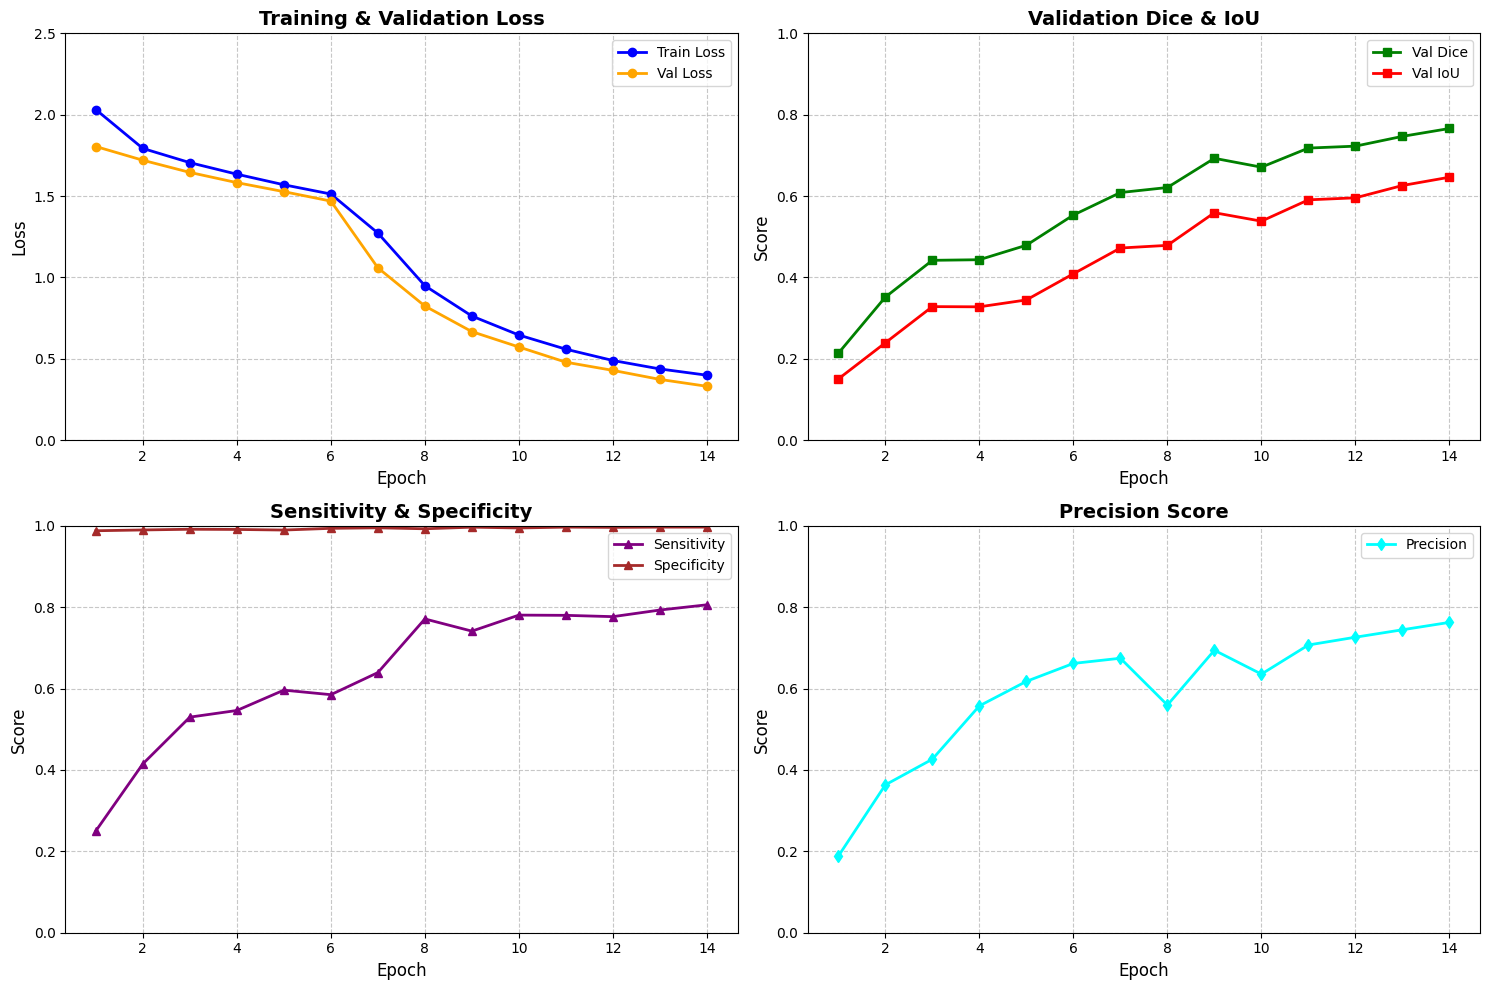

In [23]:
# 1. Load the metrics from the JSON file
json_path = "training/training_metrics.json"
try:
    with open(json_path, "r") as f:
        metrics = json.load(f)
except FileNotFoundError:
    print(f"Error: Could not find '{json_path}'.")
    metrics = []

if metrics:
    # 2. Extract lists of parameters
    epochs = [m["epoch"] for m in metrics]
    train_loss = [m["train_loss"] for m in metrics]
    val_loss = [m["val_loss"] for m in metrics]
    val_dice = [m["val_dice"] for m in metrics]
    val_iou = [m["val_iou"] for m in metrics]
    val_sens = [m["val_sensitivity"] for m in metrics]
    val_spec = [m["val_specificity"] for m in metrics]
    val_prec = [m["val_precision"] for m in metrics]

    # 3. Create a 2x2 grid of plots
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))

    # Graph 1: Train Loss vs Validation Loss (Y-axis: 0 to 3)
    axs[0, 0].plot(
        epochs, train_loss, label="Train Loss", marker="o", color="blue", linewidth=2
    )
    axs[0, 0].plot(
        epochs, val_loss, label="Val Loss", marker="o", color="orange", linewidth=2
    )
    axs[0, 0].set_title("Training & Validation Loss", fontsize=14, fontweight="bold")
    axs[0, 0].set_xlabel("Epoch", fontsize=12)
    axs[0, 0].set_ylabel("Loss", fontsize=12)
    axs[0, 0].set_ylim(0, 2.5)  # Set limit from 0 to 2.5
    axs[0, 0].legend()
    axs[0, 0].grid(True, linestyle="--", alpha=0.7)

    # Graph 2: Validation Dice and IoU (Y-axis: 0 to 1)
    axs[0, 1].plot(
        epochs, val_dice, label="Val Dice", marker="s", color="green", linewidth=2
    )
    axs[0, 1].plot(
        epochs, val_iou, label="Val IoU", marker="s", color="red", linewidth=2
    )
    axs[0, 1].set_title("Validation Dice & IoU", fontsize=14, fontweight="bold")
    axs[0, 1].set_xlabel("Epoch", fontsize=12)
    axs[0, 1].set_ylabel("Score", fontsize=12)
    axs[0, 1].set_ylim(0, 1)  # Set limit from 0 to 1
    axs[0, 1].legend()
    axs[0, 1].grid(True, linestyle="--", alpha=0.7)

    # Graph 3: Sensitivity and Specificity (Y-axis: 0 to 1)
    axs[1, 0].plot(
        epochs, val_sens, label="Sensitivity", marker="^", color="purple", linewidth=2
    )
    axs[1, 0].plot(
        epochs, val_spec, label="Specificity", marker="^", color="brown", linewidth=2
    )
    axs[1, 0].set_title("Sensitivity & Specificity", fontsize=14, fontweight="bold")
    axs[1, 0].set_xlabel("Epoch", fontsize=12)
    axs[1, 0].set_ylabel("Score", fontsize=12)
    axs[1, 0].set_ylim(0, 1)  # Set limit from 0 to 1
    axs[1, 0].legend()
    axs[1, 0].grid(True, linestyle="--", alpha=0.7)

    # Graph 4: Precision (Y-axis: 0 to 1)
    axs[1, 1].plot(
        epochs, val_prec, label="Precision", marker="d", color="cyan", linewidth=2
    )
    axs[1, 1].set_title("Precision Score", fontsize=14, fontweight="bold")
    axs[1, 1].set_xlabel("Epoch", fontsize=12)
    axs[1, 1].set_ylabel("Score", fontsize=12)
    axs[1, 1].set_ylim(0, 1)  # Set limit from 0 to 1
    axs[1, 1].legend()
    axs[1, 1].grid(True, linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()

## Model Inference


### **Patch-Based Sliding Window Inference**

This cell implements a robust inference strategy using MONAI's sliding window utility to process large 3D MRI volumes that exceed GPU memory limits. By dividing the volume into overlapping $128^3$ patches and applying a Gaussian importance weighting, the function ensures seamless transitions between patches and minimizes edge artifacts in the final probability map.


In [24]:
def run_sliding_window(input_tensor, model):
    """
    Handles the sliding window execution for a single volume.
    Uses MONAI's sliding_window_inference to manage patch-based processing.
    """

    # This specifically filters out the indexing warning coming from MONAI/PyTorch
    warnings.filterwarnings(
        "ignore", category=UserWarning, message=".*non-tuple sequence.*"
    )

    # Use mixed precision for faster inference and lower VRAM usage
    with torch.amp.autocast(
        device_type=input_tensor.device.type,
        dtype=torch.float16 if input_tensor.device.type == "cuda" else torch.bfloat16,
    ):
        # roi_size: The patch size the model was trained on (128x128x128)
        # sw_batch_size: Number of patches to process at once
        # overlap: 50% overlap between patches for smoother boundaries
        # mode="gaussian": Gives more weight to the center of patches to reduce edge artifacts
        logits = monai.inferers.sliding_window_inference(
            inputs=input_tensor,
            roi_size=(128, 128, 128),
            sw_batch_size=4,
            predictor=model,
            overlap=0.5,
            mode="gaussian",
        )

    # Convert logits to probabilities immediately
    return torch.softmax(logits, dim=1)

### **Test-Time Augmentation (TTA) with Sliding Window Inference**

This cell implements Test-Time Augmentation (TTA) by performing inference on eight different flipped orientations of the input 3D volume and averaging the results to improve segmentation stability and accuracy. It leverages the previously defined sliding window logic to process each orientation, then maps the predictions back to the original spatial orientation to produce a single, refined probability map.


In [25]:
def tta_sliding_window_inference(input_tensor, model):
    """
    Performs Test-Time Augmentation (TTA) by flipping the input across 8
    possible combinations of 3D axes and averaging the results.
    """
    # Spatial dimensions for a 3D tensor (D, H, W) are indices 2, 3, 4
    spatial_dims = (2, 3, 4)

    # Generate all 8 possible combinations of flips (including no flip)
    flip_combinations = []
    for r in range(len(spatial_dims) + 1):
        flip_combinations.extend(itertools.combinations(spatial_dims, r))

    accumulated_probs = None

    for axes in flip_combinations:
        # 1. Flip the input volume if axes are selected
        flipped_input = (
            torch.flip(input_tensor, dims=axes) if len(axes) > 0 else input_tensor
        )

        # 2. Run the modular sliding window logic from Cell 1
        probs = run_sliding_window(flipped_input, model)

        # 3. Flip the predicted probabilities back to the original orientation
        unflipped_probs = torch.flip(probs, dims=axes) if len(axes) > 0 else probs

        # 4. Accumulate results
        if accumulated_probs is None:
            accumulated_probs = unflipped_probs
        else:
            accumulated_probs += unflipped_probs

    # Average the probabilities across all 8 iterations
    avg_probs = accumulated_probs / len(flip_combinations)
    return avg_probs

## Post Processing


### **Noise Removal via Largest Connected Component Analysis**

This cell implements a geometric post-processing filter that identifies all disconnected regions within a predicted segmentation mask and preserves only the single largest contiguous mass. This technique is highly effective in medical imaging for eliminating "speckle" noise and small false-positive clusters that are biologically improbable, ensuring a cleaner and more anatomically consistent final tumor mask.


In [26]:
def get_largest_connected_component(mask):
    """
    Identifies all disconnected blobs and keeps only the largest one
    to erase background noise.
    """
    if not np.any(mask):
        return mask

    # Label disconnected components
    labeled_array, num_features = scipy.ndimage.label(mask)

    if num_features == 0:
        return mask

    # Find the largest component (excluding background 0)
    component_sizes = np.bincount(labeled_array.ravel())
    largest_component_label = component_sizes[1:].argmax() + 1

    # Create a mask containing only the largest component
    return (labeled_array == largest_component_label).astype(np.uint8)

### **Post-Processing via Morphological Operations**

This cell implements a shape-refinement pipeline using classic morphological operations to improve the geometric consistency of the segmentation. It first applies **Opening** (Erosion followed by Dilation) to erase small, isolated "speckle" noise that may have been incorrectly predicted in healthy tissue, followed by **Closing** (Dilation followed by Erosion) to fill in tiny internal gaps or holes within the predicted tumor mass, resulting in a cleaner and more biologically plausible mask.


In [27]:
def apply_morphological_refinement(mask, iterations=1):
    """
    Refines the tumor mask by removing noise and filling internal holes.
    """
    mask = mask.astype(bool)

    # 1. Opening: Erases small isolated pixels (noise) outside the tumor
    # Corrected call: scipy.ndimage.binary_opening
    mask = scipy.ndimage.binary_opening(mask, iterations=iterations)

    # 2. Closing: Fills in small gaps or holes inside the tumor mass
    # Corrected call: scipy.ndimage.binary_closing
    mask = scipy.ndimage.binary_closing(mask, iterations=iterations)

    return mask.astype(np.uint8)

### **Integrated Modular Post-Processing Pipeline**

This cell coordinates the final refinement stage of the segmentation workflow by sequentially applying the Largest Connected Component (LCC) analysis and morphological operations to each predicted tumor class. By isolating each class and systematically removing noise while smoothing boundaries, the function consolidates discrete regional predictions into a single, high-fidelity 3D mask ready for clinical visualization or final evaluation.


In [28]:
def postprocess_prediction(pred_mask):
    """
    Applies LCC and Morphological operations class-by-class.
    """
    # Ensure input is a numpy array
    if hasattr(pred_mask, "cpu"):
        pred_mask = pred_mask.cpu().numpy()

    processed_mask = np.zeros_like(pred_mask)

    # Process each tumor class separately (1, 2, 3)
    for class_id in np.unique(pred_mask):
        if class_id == 0:
            continue  # Skip background

        class_mask = (pred_mask == class_id).astype(np.uint8)

        # 1. Keep largest component
        class_mask = get_largest_connected_component(class_mask)

        # 2. Refine shape
        class_mask = apply_morphological_refinement(class_mask)

        processed_mask[class_mask > 0] = class_id

    return processed_mask

## Visualization of Results


### **Multi-Modal Data Loading and Inference Pipeline**

This cell executes the full evaluation pipeline for a single patient subject. It begins by loading the four raw MRI modalities (FLAIR, T1, T1ce, T2) using Nibabel and standardizing their intensities through Z-score normalization. The modalities are then stacked into a 4D tensor and passed through the trained nnU-Net using a combination of **Sliding Window Inference** and **Test-Time Augmentation (TTA)**, which ensemble-averages multiple orientations to produce a high-confidence segmentation mask.


In [29]:
print("Do you want prediction for new random patient? (y/n)")
if input().lower() == "y":
    # 1. Pick a random patient from the list
    pt_id = random.choice(pt_ids)
    print(f"Visualizing Patient ID: {pt_id}")
    new_prediction = True
else:
    print("Skipping prediction.")
    pt_id = "00000"
    new_prediction = False

# 3. Load the data using nibabel
flair_img = (
    nib.load(f"raw/BraTS2021_{pt_id}/BraTS2021_{pt_id}_flair.nii.gz")
    .get_fdata()
    .astype(np.float32)
)
t1_img = (
    nib.load(f"raw/BraTS2021_{pt_id}/BraTS2021_{pt_id}_t1.nii.gz")
    .get_fdata()
    .astype(np.float32)
)
t1ce_img = (
    nib.load(f"raw/BraTS2021_{pt_id}/BraTS2021_{pt_id}_t1ce.nii.gz")
    .get_fdata()
    .astype(np.float32)
)
t2_img = (
    nib.load(f"raw/BraTS2021_{pt_id}/BraTS2021_{pt_id}_t2.nii.gz")
    .get_fdata()
    .astype(np.float32)
)

# Load and remap ground truth mask (BraTS class 4 becomes 3)
true_mask = (
    nib.load(f"raw/BraTS2021_{pt_id}/BraTS2021_{pt_id}_seg.nii.gz")
    .get_fdata()
    .astype(np.uint8)
)
true_mask[true_mask == 4] = 3

if new_prediction:
    # 4. Prepare data for the model
    # Stack the 4 modalities into a shape of (4, H, W, D)
    input_tensor = np.stack([t1_img, t1ce_img, t2_img, flair_img], axis=0)

    # Simple normalization (z-score) per channel
    for i in range(4):
        input_tensor[i] = (input_tensor[i] - np.mean(input_tensor[i])) / (
            np.std(input_tensor[i]) + 1e-8
        )

    # Convert to PyTorch tensor, add batch dimension -> (1, 4, H, W, D), and move to GPU
    input_tensor = (
        torch.tensor(input_tensor, dtype=torch.float32).unsqueeze(0).to(device)
    )

    # 5. Generate Model Prediction using Sliding Window + TTA
    model.eval()

    with torch.no_grad():
        # Call TTA Sliding Window function
        avg_probs = tta_sliding_window_inference(input_tensor=input_tensor, model=model)

        # Get predicted class via argmax and remove batch dimension
        pred_mask = torch.argmax(avg_probs, dim=1).squeeze(0).cpu().numpy()
else:
    pred_mask = np.load("training/pred_mask_00000.npy")

Do you want prediction for new random patient? (y/n)
Skipping prediction.


### **2D Segmentation Slice Extraction and Comparative Visualization**

This cell selects and extracts the most relevant 2D axial slice—specifically the one containing the largest tumor volume—to provide a detailed visual assessment of the model's performance. It rotates the slices to a standard clinical orientation and displays a four-panel comparison featuring the raw FLAIR MRI, the expert Ground Truth, the raw nnU-Net prediction, and the final post-processed mask, allowing for immediate qualitative verification of the entire segmentation and refinement pipeline.


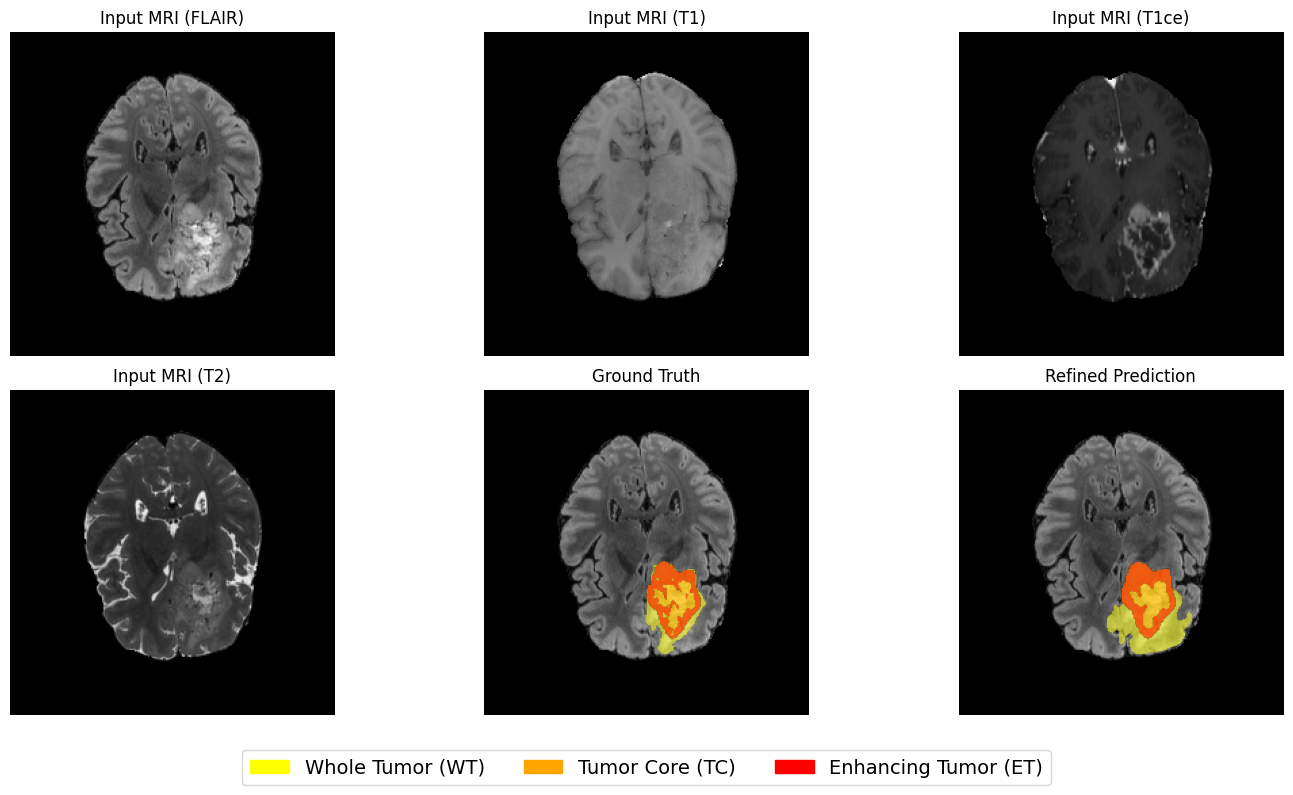

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# Select the best 2D slice to visualize
tumor_area_per_slice = np.sum(true_mask > 0, axis=(0, 1))
best_slice_idx = np.argmax(tumor_area_per_slice)

# Fallback to middle slice if no tumor
if tumor_area_per_slice[best_slice_idx] == 0:
    best_slice_idx = true_mask.shape[2] // 2

# Extract the 2D slices for ALL 4 modalities and masks
flair_slice = flair_img[:, :, best_slice_idx]
t1_slice = t1_img[:, :, best_slice_idx]
t1ce_slice = t1ce_img[:, :, best_slice_idx]
t2_slice = t2_img[:, :, best_slice_idx]

true_mask_slice = true_mask[:, :, best_slice_idx]
pred_mask_slice = pred_mask[:, :, best_slice_idx]

# Apply the post-processing pipeline (from previous cells)
processed_pred_slice = postprocess_prediction(pred_mask_slice)

# Rotate slices 90 degrees (Fixes sideways orientation from Nibabel)
flair_slice = np.rot90(flair_slice)
t1_slice = np.rot90(t1_slice)
t1ce_slice = np.rot90(t1ce_slice)
t2_slice = np.rot90(t2_slice)
true_mask_slice = np.rot90(true_mask_slice)
processed_pred_slice = np.rot90(processed_pred_slice)

# --- NEW: Separate Masks into Specific Regions for Layering ---
# We use .data to safely evaluate the array values without mask interference
tm_data = true_mask_slice
pm_data = processed_pred_slice

# Ground Truth Layers (1s array used just to apply the solid color)
wt_true = np.ma.masked_where(tm_data == 0, np.ones_like(tm_data))
tc_true = np.ma.masked_where((tm_data != 1) & (tm_data != 3), np.ones_like(tm_data))
et_true = np.ma.masked_where(tm_data != 3, np.ones_like(tm_data))

# Prediction Layers
wt_pred = np.ma.masked_where(pm_data == 0, np.ones_like(pm_data))
tc_pred = np.ma.masked_where((pm_data != 1) & (pm_data != 3), np.ones_like(pm_data))
et_pred = np.ma.masked_where(pm_data != 3, np.ones_like(pm_data))

# Define individual single-color maps
cmap_wt = ListedColormap(["yellow"])
cmap_tc = ListedColormap(["orange"])
cmap_et = ListedColormap(["red"])

# Create Legend Patches
legend_elements = [
    mpatches.Patch(color="yellow", label="Whole Tumor (WT)"),
    mpatches.Patch(color="orange", label="Tumor Core (TC)"),
    mpatches.Patch(color="red", label="Enhancing Tumor (ET)"),
]

# Plotting
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 1. FLAIR
axes[0, 0].imshow(flair_slice, cmap="gray")
axes[0, 0].set_title("Input MRI (FLAIR)")

# 2. T1
axes[0, 1].imshow(t1_slice, cmap="gray")
axes[0, 1].set_title("Input MRI (T1)")

# 3. T1ce
axes[0, 2].imshow(t1ce_slice, cmap="gray")
axes[0, 2].set_title("Input MRI (T1ce)")

# 4. T2
axes[1, 0].imshow(t2_slice, cmap="gray")
axes[1, 0].set_title("Input MRI (T2)")

# 5. Ground Truth (Stacked Layers)
axes[1, 1].imshow(flair_slice, cmap="gray")
axes[1, 1].imshow(wt_true, cmap=cmap_wt, alpha=0.5)  # Bottom layer (Yellow)
axes[1, 1].imshow(tc_true, cmap=cmap_tc, alpha=0.5)  # Middle layer (Orange)
axes[1, 1].imshow(et_true, cmap=cmap_et, alpha=0.5)  # Top layer (Red)
axes[1, 1].set_title("Ground Truth")

# 6. Prediction (Stacked Layers)
axes[1, 2].imshow(flair_slice, cmap="gray")
axes[1, 2].imshow(wt_pred, cmap=cmap_wt, alpha=0.5)  # Bottom layer
axes[1, 2].imshow(tc_pred, cmap=cmap_tc, alpha=0.5)  # Middle layer
axes[1, 2].imshow(et_pred, cmap=cmap_et, alpha=0.5)  # Top layer
axes[1, 2].set_title("Refined Prediction")

# Turn off axis markers
for ax in axes.flat:
    ax.axis("off")

# --- NEW: Horizontal Legend Below the Figure ---
fig.legend(
    handles=legend_elements,
    loc="lower center",  # Centers it at the bottom
    bbox_to_anchor=(0.5, 0.0),
    ncol=3,  # Aligns the 3 items in a single horizontal row
    fontsize=14,
)

plt.tight_layout()
# Ensures the bottom legend doesn't get cut off by tight_layout
fig.subplots_adjust(bottom=0.1)
plt.show()